In [1]:
import os
import cv2
import numpy as np
import pandas as  pd
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchsummary import summary
from model.resnet import Resnet34Triplet

In [2]:
flag_gpu_available = torch.cuda.is_available()
if flag_gpu_available:
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(device)

cuda


In [3]:
checkpoint = torch.load('model/model_resnet34_triplet.pt', map_location=device)
model = Resnet34Triplet(embedding_dimension=checkpoint['embedding_dimension'])
model.load_state_dict(checkpoint['model_state_dict'])
best_distance_threshold = checkpoint['best_distance_threshold']

model.to(device)
model.eval()

Resnet34Triplet(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

In [4]:
summary(model, input_size = (3, 112, 112), batch_size = -1)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 56, 56]           9,408
       BatchNorm2d-2           [-1, 64, 56, 56]             128
              ReLU-3           [-1, 64, 56, 56]               0
         MaxPool2d-4           [-1, 64, 28, 28]               0
            Conv2d-5           [-1, 64, 28, 28]          36,864
       BatchNorm2d-6           [-1, 64, 28, 28]             128
              ReLU-7           [-1, 64, 28, 28]               0
            Conv2d-8           [-1, 64, 28, 28]          36,864
       BatchNorm2d-9           [-1, 64, 28, 28]             128
             ReLU-10           [-1, 64, 28, 28]               0
       BasicBlock-11           [-1, 64, 28, 28]               0
           Conv2d-12           [-1, 64, 28, 28]          36,864
      BatchNorm2d-13           [-1, 64, 28, 28]             128
             ReLU-14           [-1, 64,

In [5]:
preprocess = transforms.Compose([
  transforms.ToPILImage(),
  transforms.Resize(size=(140,140)),  # Pre-trained model uses 140x140 input images
  transforms.ToTensor(),
  transforms.Normalize(
      mean=[0.6071, 0.4609, 0.3944],  # Normalization settings for the model, the calculated mean and std values
      std=[0.2457, 0.2175, 0.2129]     # for the RGB channels of the tightly-cropped glint360k face dataset
  )
])

In [8]:
img = cv2.imread('images/face_1.jpg')  # Or from a cv2 video capture stream

# Note that you need to use a face detection model here to crop the face from the image and then
#  create a new face image object that will be inputted to the facial recognition model later.

# Convert the image from BGR color (which OpenCV uses) to RGB color
img = img[:, :, ::-1]

img = preprocess(img)
img = img.unsqueeze(0)
img = img.to(device)

embedding = model(img)

# Turn embedding Torch Tensor to Numpy array
#embedding = embedding.cpu().detach().numpy()

In [9]:
print(embedding.shape)

torch.Size([1, 512])


In [10]:
print(img.shape)

torch.Size([1, 3, 140, 140])


In [11]:
invTransform = transforms.Compose(
                [transforms.Normalize(mean=[0., 0., 0.], std=[1/0.6071, 1/0.4609, 1/0.3944]),
                 transforms.Normalize(mean=[-0.2457, -0.2175, -0.2129], std=[1, 1, 1]),
                ])
img = invTransform(img)

In [12]:
print(img.shape)

torch.Size([1, 3, 140, 140])


In [13]:
img[0].shape

torch.Size([3, 140, 140])

In [14]:
img = torch.permute(img[0], (1, 2, 0))

In [15]:
print(img.shape)

torch.Size([140, 140, 3])


In [16]:
print(img.shape)
img = img.cpu().detach().numpy()
print(img.shape)

torch.Size([140, 140, 3])
(140, 140, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


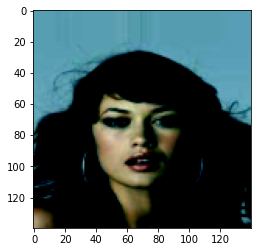

In [17]:
plt.imshow(img)

In [19]:
img2 = cv2.imread('images/face_2.jpg')  # Or from a cv2 video capture stream

# Note that you need to use a face detection model here to crop the face from the image and then
#  create a new face image object that will be inputted to the facial recognition model later.

# Convert the image from BGR color (which OpenCV uses) to RGB color
img2 = img2[:, :, ::-1]

img2 = preprocess(img2)
img2 = img2.unsqueeze(0)
img2 = img2.to(device)

embedding2 = model(img2)

# Turn embedding Torch Tensor to Numpy array
#embedding2 = embedding2.cpu().detach().numpy()

In [20]:
embedding2.shape

torch.Size([1, 512])

In [21]:
e1 = torch.flatten(embedding)
e2 = torch.flatten(embedding2)
print(e2.shape)

torch.Size([512])


In [22]:
similarity = nn.CosineSimilarity(dim=0, eps=1e-6)

In [23]:
score = similarity(e1, e2)
print(score)

tensor(0.6389, device='cuda:0', grad_fn=<DivBackward0>)


In [24]:
def create_embedding(img_pth, face_model):
    img = cv2.imread(img_pth)  # Or from a cv2 video capture stream

    # Note that you need to use a face detection model here to crop the face from the image and then
    #  create a new face image object that will be inputted to the facial recognition model later.

    # Convert the image from BGR color (which OpenCV uses) to RGB color
    img = img[:, :, ::-1]
    
    transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize(size=(140,140)),  # Pre-trained model uses 140x140 input images
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.6071, 0.4609, 0.3944],  # Normalization settings for the model, the calculated mean and std values
                    std=[0.2457, 0.2175, 0.2129]     # for the RGB channels of the tightly-cropped glint360k face dataset
                )
    ])
    
    img = transform(img)
    img = img.unsqueeze(0)
    img = img.to(device)

    embedding = face_model(img)
    embedding = torch.flatten(embedding)
    embedding = embedding.cpu().detach()

    # Turn embedding Torch Tensor to Numpy array
    #embedding = embedding.cpu().detach().numpy()
    return img, embedding

In [25]:
def compute_sim_score(sim_metric, embedding1, embedding2):
    score = sim_metric(embedding1, embedding2)
    return score

In [26]:
def display_image(img):
    invTransform = transforms.Compose(
                [transforms.Normalize(mean=[0., 0., 0.], std=[1/0.6071, 1/0.4609, 1/0.3944]),
                 transforms.Normalize(mean=[-0.2457, -0.2175, -0.2129], std=[1, 1, 1]),
                ])
    
    img = invTransform(img)
    img = torch.permute(img[0], (1, 2, 0))
    img = img.cpu().detach().numpy()
    plt.imshow(img)
    plt.show

In [27]:
img_pth1 = 'images/Abdullah_al-Attiyah_0001.jpg'
#img_pth1 = 'images/face_1.jpg'
img1, e1 = create_embedding(img_pth1, model)

In [28]:
img_pth2 = 'images/Abdullah_al-Attiyah_0003.jpg'
img2, e2 = create_embedding(img_pth2, model)

In [29]:
sc = compute_sim_score(similarity, e1, e2)
print(sc)

tensor(0.7359)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


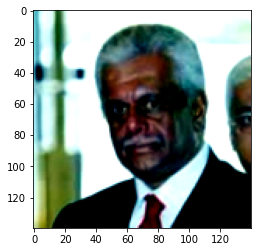

In [30]:
display_image(img1)

In [31]:
px1 = pd.DataFrame(e1)

In [32]:
px2 = pd.DataFrame(e2)

In [33]:
px = pd.concat([px1, px2], axis=1, ignore_index=True)
px

,0,1
0,0.073802,0.008429
1,-0.075669,-0.078258
2,-0.056437,-0.075916
3,0.087387,0.001851
4,-0.098773,-0.092888
...,...,...
507,0.027126,0.016983
508,-0.023371,0.009086
509,0.031038,0.031919
510,0.073560,0.063779


In [34]:
px3 = pd.DataFrame(e2)

In [35]:
px = pd.concat([px, px3], axis=1, ignore_index=True)
px

,0,1,2
0,0.073802,0.008429,0.008429
1,-0.075669,-0.078258,-0.078258
2,-0.056437,-0.075916,-0.075916
3,0.087387,0.001851,0.001851
4,-0.098773,-0.092888,-0.092888
...,...,...,...
507,0.027126,0.016983,0.016983
508,-0.023371,0.009086,0.009086
509,0.031038,0.031919,0.031919
510,0.073560,0.063779,0.063779


In [126]:
px.set_axis([1, 'B', 'C'], axis='columns', inplace=True)

In [130]:
px['B']

0      0.008429
1     -0.078258
2     -0.075916
3      0.001851
4     -0.092888
         ...   
507    0.016983
508    0.009086
509    0.031919
510    0.063779
511   -0.026017
Name: B, Length: 512, dtype: float32

In [140]:
list2 = px[1].tolist()

In [135]:
len(list)

512

In [136]:
list

[0.008429440669715405,
 -0.07825811207294464,
 -0.07591603696346283,
 0.0018507309723645449,
 -0.09288787841796875,
 -0.01755114644765854,
 -0.031777989119291306,
 -0.011014468036592007,
 0.051807280629873276,
 0.012737605720758438,
 -0.02889241836965084,
 0.02290217950940132,
 0.04310963675379753,
 0.0702623650431633,
 -0.02858342044055462,
 0.047962334007024765,
 0.03339507803320885,
 0.013484857976436615,
 -0.03723561391234398,
 0.07274258881807327,
 -0.006706702057272196,
 0.022289523854851723,
 0.0642756000161171,
 0.005362282041460276,
 -0.0005306604434736073,
 0.02013321779668331,
 0.019766177982091904,
 -0.06959351152181625,
 -0.05342933163046837,
 -0.014306074939668179,
 0.004351743962615728,
 -0.01884627714753151,
 0.08574315160512924,
 0.012190272100269794,
 0.009693991392850876,
 -0.0030901695135980844,
 0.023065896704792976,
 0.035737622529268265,
 -0.03761660307645798,
 0.02639680728316307,
 -0.04922071099281311,
 0.006304062437266111,
 0.04595758765935898,
 -0.0282432287

In [141]:
b2 = torch.FloatTensor(list2)

In [138]:
b.shape

torch.Size([512])

In [142]:
sc = compute_sim_score(similarity, b, b2)
print(sc)

tensor(0.7359)


In [148]:
a = torch.Tensor([121, 100, 21, 4])
a

tensor([121., 100.,  21.,   4.])

In [150]:
torch.topk(a.flatten(), 3).indices

tensor([0, 1, 2])

In [79]:
def create_embedding(imgs_path, save_name, face_model):
    transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize(size=(140,140)),  # Pre-trained model uses 140x140 input images
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.6071, 0.4609, 0.3944],  # Normalization settings for the model, the calculated mean and std values
                    std=[0.2457, 0.2175, 0.2129]     # for the RGB channels of the tightly-cropped glint360k face dataset
                )
    ])
    
    img_names = [os.path.join(imgs_path, x) for x in os.listdir(imgs_path)]
    face_names = []
    embeddings_list = []
    
    for index, img_name in enumerate(img_names):
        if index % 2 == 0:
            print("Computing embedding... {}/{}".format(index, len(img_names)))
        
        #print(img_name)
        face_names.append(img_name)
        #print(face_names)
        
        img = cv2.imread(img_name)  # Or from a cv2 video capture stream

        # Note that you need to use a face detection model here to crop the face from the image and then
        #  create a new face image object that will be inputted to the facial recognition model later.

        # Convert the image from BGR color (which OpenCV uses) to RGB color
        img = img[:, :, ::-1]
    
        img = transform(img)
        img = img.unsqueeze(0)
        img = img.to(device)

        embedding = face_model(img)
        embedding = torch.flatten(embedding)
        embedding = embedding.cpu().detach().numpy()
        
#         embedding = embedding.cpu().detach().numpy()
#         embedding = np.squeeze(embedding)
        embeddings_list.append(embedding)
#         result = pd.DataFrame()
#         px = pd.DataFrame(embedding)
#         result = pd.concat([result, px], axis=1, ignore_index=True)

    result = pd.DataFrame(embeddings_list).T
    result.columns = img_names
    result.to_csv(save_name)
    #print(img_names)
    
    return result

In [80]:
imgs_path = 'images/'
save_name = 'train_embeddings.csv'
create_embedding(imgs_path, save_name, model)

Computing embedding... 0/5
Computing embedding... 2/5
Computing embedding... 4/5


,images/Abdullah_al-Attiyah_0001.jpg,images/Abdullah_al-Attiyah_0002.jpg,images/Abdullah_al-Attiyah_0003.jpg,images/face_1.jpg,images/face_2.jpg
0,0.073802,0.065443,0.008429,0.023905,0.017484
1,-0.075669,-0.025421,-0.078258,-0.017024,0.006470
2,-0.056437,-0.050037,-0.075916,-0.037616,0.079641
3,0.087387,-0.027361,0.001851,-0.068096,-0.065787
4,-0.098773,-0.070034,-0.092888,-0.010352,0.021746
...,...,...,...,...,...
507,0.027126,0.031301,0.016983,-0.039129,-0.108022
508,-0.023371,0.018220,0.009086,0.029670,-0.023078
509,0.031038,0.033506,0.031919,0.017231,0.008174
510,0.073560,0.024925,0.063779,0.017141,0.071291


In [154]:
imgs_path = 'gen_images/'
save_name = 'gen_embeddings.csv'
create_embedding(imgs_path, save_name, model)

Computing embedding... 0/3
Computing embedding... 2/3


,gen_images/Abdullah_al-Attiyah_0001.jpg,gen_images/Abdullah_al-Attiyah_0002.jpg,gen_images/Abdullah_al-Attiyah_0003.jpg
0,0.073802,0.065443,0.008429
1,-0.075669,-0.025421,-0.078258
2,-0.056437,-0.050037,-0.075916
3,0.087387,-0.027361,0.001851
4,-0.098773,-0.070034,-0.092888
...,...,...,...
507,0.027126,0.031301,0.016983
508,-0.023371,0.018220,0.009086
509,0.031038,0.033506,0.031919
510,0.073560,0.024925,0.063779


In [155]:
imgs_path = 'train_images/'
save_name = 'train_embeddings.csv'
create_embedding(imgs_path, save_name, model)

Computing embedding... 0/5
Computing embedding... 2/5
Computing embedding... 4/5


,train_images/Abdullah_al-Attiyah_0001.jpg,train_images/Abdullah_al-Attiyah_0002.jpg,train_images/Abdullah_al-Attiyah_0003.jpg,train_images/face_1.jpg,train_images/face_2.jpg
0,0.073802,0.065443,0.008429,0.023905,0.017484
1,-0.075669,-0.025421,-0.078258,-0.017024,0.006470
2,-0.056437,-0.050037,-0.075916,-0.037616,0.079641
3,0.087387,-0.027361,0.001851,-0.068096,-0.065787
4,-0.098773,-0.070034,-0.092888,-0.010352,0.021746
...,...,...,...,...,...
507,0.027126,0.031301,0.016983,-0.039129,-0.108022
508,-0.023371,0.018220,0.009086,0.029670,-0.023078
509,0.031038,0.033506,0.031919,0.017231,0.008174
510,0.073560,0.024925,0.063779,0.017141,0.071291


In [82]:
df1 = pd.read_csv('train_embeddings.csv', index_col=0)
df1

,images/Abdullah_al-Attiyah_0001.jpg,images/Abdullah_al-Attiyah_0002.jpg,images/Abdullah_al-Attiyah_0003.jpg,images/face_1.jpg,images/face_2.jpg
0,0.073802,0.065443,0.008429,0.023905,0.017484
1,-0.075669,-0.025421,-0.078258,-0.017024,0.006470
2,-0.056437,-0.050037,-0.075916,-0.037616,0.079641
3,0.087387,-0.027361,0.001851,-0.068096,-0.065787
4,-0.098773,-0.070034,-0.092888,-0.010352,0.021746
...,...,...,...,...,...
507,0.027126,0.031301,0.016983,-0.039129,-0.108022
508,-0.023371,0.018220,0.009086,0.029670,-0.023078
509,0.031038,0.033506,0.031919,0.017231,0.008174
510,0.073560,0.024925,0.063779,0.017141,0.071291


In [92]:
out1 = df1['images/Abdullah_al-Attiyah_0001.jpg']
print(out1)

0      0.073802
1     -0.075669
2     -0.056437
3      0.087387
4     -0.098773
         ...   
507    0.027126
508   -0.023371
509    0.031038
510    0.073560
511    0.023277
Name: images/Abdullah_al-Attiyah_0001.jpg, Length: 512, dtype: float64


In [108]:
out3 = df1['images/Abdullah_al-Attiyah_0002.jpg']
print(out3)

0      0.065443
1     -0.025421
2     -0.050037
3     -0.027361
4     -0.070034
         ...   
507    0.031301
508    0.018220
509    0.033506
510    0.024925
511    0.031172
Name: images/Abdullah_al-Attiyah_0002.jpg, Length: 512, dtype: float64


In [109]:
out2 = df1['images/face_2.jpg']
print(out2.shape)

(512,)


In [111]:
def compute_sim_score(sim_metric, embedding1, embedding2):
    embedding1 = torch.Tensor(embedding1)
    embedding2 = torch.Tensor(embedding2)
    score = sim_metric(embedding1, embedding2)
    return score

In [113]:
compute_sim_score(similarity, out1, out3).item()

0.47757595777511597

In [165]:
def compute_all_scores(gen_imgs_path, train_imgs_path, gen_csv, train_csv, save_name, sim_metric=similarity):
    transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize(size=(140,140)),  # Pre-trained model uses 140x140 input images
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.6071, 0.4609, 0.3944],  # Normalization settings for the model, the calculated mean and std values
                    std=[0.2457, 0.2175, 0.2129]     # for the RGB channels of the tightly-cropped glint360k face dataset
                )
    ])
    
    df_gen = pd.read_csv(gen_csv, index_col=0)
    gen_img_names = [os.path.join(gen_imgs_path, x) for x in os.listdir(gen_imgs_path)]
    gen_face_names = []
    
    df_train = pd.read_csv(train_csv, index_col=0)
    train_img_names = [os.path.join(train_imgs_path, x) for x in os.listdir(train_imgs_path)]
    train_face_names = []
    
    g_score_list = []
    
    for g_index, gen_img_name in enumerate(gen_img_names):
        gen_img_embed = df_gen[gen_img_name]
        gen_img_embed = torch.Tensor(gen_img_embed)
        
        t_score_list = []
        
        for t_index, train_img_name in enumerate(train_img_names):
            train_img_embed = df_train[train_img_name]
            train_img_embed = torch.Tensor(train_img_embed)
            
            score = sim_metric(gen_img_embed, train_img_embed)
            #print(score)
            t_score_list.append(score.item())
        
        #print(t_score_list)
        
        g_score_list.append(t_score_list)
        
    #print(g_score_list)
    
    result = pd.DataFrame(g_score_list)
    result.columns = train_img_names
    result.index = gen_img_names
    result.to_csv(save_name)
    
    return result

In [166]:
gen_imgs_path = 'gen_images/'
train_imgs_path = 'train_images/'
gen_csv = 'gen_embeddings.csv'
train_csv = 'train_embeddings.csv'
save_name = 'output.csv'

compute_all_scores(gen_imgs_path, train_imgs_path, gen_csv, train_csv, save_name)

,train_images/Abdullah_al-Attiyah_0001.jpg,train_images/Abdullah_al-Attiyah_0002.jpg,train_images/Abdullah_al-Attiyah_0003.jpg,train_images/face_1.jpg,train_images/face_2.jpg
gen_images/Abdullah_al-Attiyah_0001.jpg,1.000000,0.477576,0.735857,0.338404,0.228799
gen_images/Abdullah_al-Attiyah_0002.jpg,0.477576,1.000000,0.742356,0.653180,0.348559
gen_images/Abdullah_al-Attiyah_0003.jpg,0.735857,0.742356,1.000000,0.446007,0.171687


In [201]:
df = pd.read_csv(save_name, index_col=0)
df

,train_images/Abdullah_al-Attiyah_0001.jpg,train_images/Abdullah_al-Attiyah_0002.jpg,train_images/Abdullah_al-Attiyah_0003.jpg,train_images/face_1.jpg,train_images/face_2.jpg
gen_images/Abdullah_al-Attiyah_0001.jpg,1.000000,0.477576,0.735857,0.338404,0.228799
gen_images/Abdullah_al-Attiyah_0002.jpg,0.477576,1.000000,0.742356,0.653180,0.348559
gen_images/Abdullah_al-Attiyah_0003.jpg,0.735857,0.742356,1.000000,0.446007,0.171687


In [202]:
maxValues = df.max(axis=1)
maxValueIndex = df.idxmax(axis=1)
print(maxValues)
print(maxValueIndex)

gen_images/Abdullah_al-Attiyah_0001.jpg    1.0
gen_images/Abdullah_al-Attiyah_0002.jpg    1.0
gen_images/Abdullah_al-Attiyah_0003.jpg    1.0
dtype: float64
gen_images/Abdullah_al-Attiyah_0001.jpg    train_images/Abdullah_al-Attiyah_0001.jpg
gen_images/Abdullah_al-Attiyah_0002.jpg    train_images/Abdullah_al-Attiyah_0002.jpg
gen_images/Abdullah_al-Attiyah_0003.jpg    train_images/Abdullah_al-Attiyah_0003.jpg
dtype: object


In [245]:
for i in np.arange(3):
    print(i)
    df1 = df.loc[df[maxValueIndex[i]] == maxValues[i]]
    print(df1.index[0], maxValues[i], maxValueIndex[i])

0
gen_images/Abdullah_al-Attiyah_0001.jpg 1.0 train_images/Abdullah_al-Attiyah_0001.jpg
1
gen_images/Abdullah_al-Attiyah_0002.jpg 1.0 train_images/Abdullah_al-Attiyah_0002.jpg
2
gen_images/Abdullah_al-Attiyah_0003.jpg 1.0 train_images/Abdullah_al-Attiyah_0003.jpg


In [215]:
def pandas_rank_based(df, n_max):
    #n_max.index = df.index
    df_rank = df.stack(dropna=False).groupby(level=0).rank\
               (ascending=False, method='first').unstack()
    selected = df_rank.le(n_max, axis=1)
    return df[selected]

In [223]:
sel_df = pandas_rank_based(df, 3)
sel_df

,train_images/Abdullah_al-Attiyah_0001.jpg,train_images/Abdullah_al-Attiyah_0002.jpg,train_images/Abdullah_al-Attiyah_0003.jpg,train_images/face_1.jpg,train_images/face_2.jpg
gen_images/Abdullah_al-Attiyah_0001.jpg,1.000000,0.477576,0.735857,NaN,NaN
gen_images/Abdullah_al-Attiyah_0002.jpg,NaN,1.000000,0.742356,0.65318,NaN
gen_images/Abdullah_al-Attiyah_0003.jpg,0.735857,0.742356,1.000000,NaN,NaN


In [219]:
df.index[0]

'gen_images/Abdullah_al-Attiyah_0001.jpg'

In [218]:
df.columns[0]

'train_images/Abdullah_al-Attiyah_0001.jpg'

In [226]:
sel_df.loc[sel_df['train_images/Abdullah_al-Attiyah_0001.jpg'] != np.NaN]

,train_images/Abdullah_al-Attiyah_0001.jpg,train_images/Abdullah_al-Attiyah_0002.jpg,train_images/Abdullah_al-Attiyah_0003.jpg,train_images/face_1.jpg,train_images/face_2.jpg
gen_images/Abdullah_al-Attiyah_0001.jpg,1.000000,0.477576,0.735857,NaN,NaN
gen_images/Abdullah_al-Attiyah_0002.jpg,NaN,1.000000,0.742356,0.65318,NaN
gen_images/Abdullah_al-Attiyah_0003.jpg,0.735857,0.742356,1.000000,NaN,NaN
